# 04 — Error analysis of the final model

Inputs written by `python -m src.train`:
* `reports/predictions_test.csv` — final model on the **test set** (evaluated once, 292 houses)
* `reports/predictions_oof_train.csv` — **out-of-fold** predictions on train (each house predicted by a model that never saw it; 1,168 houses) — more data per neighborhood than the test set
* `models/final_model.joblib` — the fitted final pipeline (for permutation importance)

Nothing here changes the model; this is analysis only.

In [1]:
import sys, json; sys.path.insert(0, "..")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from src.data import load_data, split_data
from src.evaluate import all_metrics, rmsle
from src.plotting import usd_k, setup_style, legend_outside, BLUE, RED, GRAY

setup_style()
R = Path("../reports"); FIG = R / "figures"
test = pd.read_csv(R / "predictions_test.csv", index_col="row")
oof = pd.read_csv(R / "predictions_oof_train.csv", index_col="row")
X_train, X_test, y_train, y_test = split_data(load_data())
for d in (test, oof):
    d["resid"] = d.actual - d.predicted                    # $, >0 = model too cheap
    d["pct_err"] = d.resid.abs() / d.actual * 100           # absolute % error
    d["log_err"] = np.abs(np.log1p(d.actual) - np.log1p(d.predicted))
facts = {}   # every number used in reports/insights.md is stored here
m = all_metrics(test.actual, test.predicted)
print("test:", {k: round(v, 3) for k, v in m.items()})
m_oof = all_metrics(oof.actual, oof.predicted)
print("oof :", {k: round(v, 3) for k, v in m_oof.items()})
facts.update(test_mae=m["MAE"], test_rmsle=m["RMSLE"], oof_mae=m_oof["MAE"], oof_rmsle=m_oof["RMSLE"],
             test_median_pct_err=test.pct_err.median(), test_mean_pct_err=test.pct_err.mean())
print(f"median abs % error (test): {test.pct_err.median():.1f}%   mean: {test.pct_err.mean():.1f}%")

test: {'MAE': 16391.333, 'RMSE': 30979.506, 'RMSLE': 0.136, 'R2': 0.875}
oof : {'MAE': 15813.54, 'RMSE': 27438.982, 'RMSLE': 0.128, 'R2': 0.874}
median abs % error (test): 5.9%   mean: 9.3%


## 1. Predicted vs actual (log axes) and residuals vs price

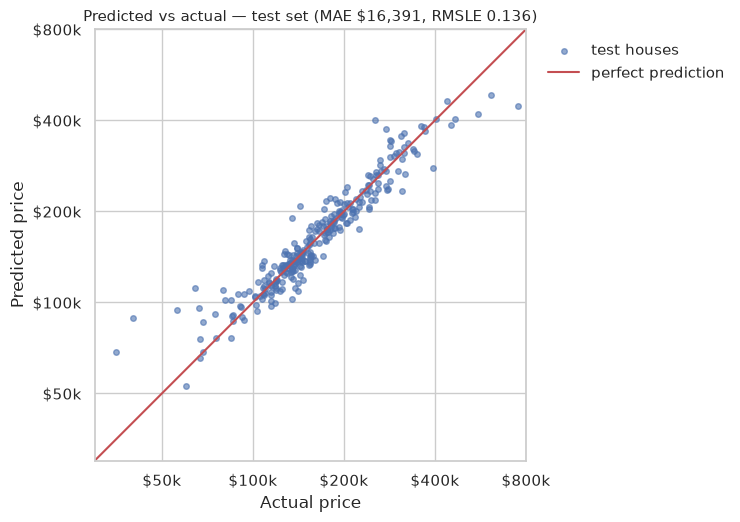

In [2]:
fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.scatter(test.actual, test.predicted, s=16, alpha=.6, color=BLUE, label="test houses")
lo, hi = 3e4, 8e5
ax.plot([lo, hi], [lo, hi], color=RED, lw=1.5, label="perfect prediction")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ticks = [50e3, 100e3, 200e3, 400e3, 800e3]
for a in (ax.xaxis, ax.yaxis):
    a.set_major_locator(plt.FixedLocator(ticks)); a.set_major_formatter(usd_k); a.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("Actual price"); ax.set_ylabel("Predicted price")
ax.set_title(f"Predicted vs actual — test set (MAE ${m['MAE']:,.0f}, RMSLE {m['RMSLE']:.3f})")
legend_outside(ax); ax.set_aspect("equal")
plt.savefig(FIG / "04_pred_vs_actual.png", dpi=130); plt.show()

                         n  mean_price      MAE  median_pct_err  bias_mean_resid
price_bin                                                                       
(34899.999, 124000.0]  295    100760.7  11682.3             8.0          -5723.5
(124000.0, 147000.0]   294    135884.3  10075.5             5.1          -1235.3
(147000.0, 179280.0]   287    163442.8  11967.5             5.5            503.8
(179280.0, 230000.0]   295    201158.6  13238.3             4.8            871.4
(230000.0, 755000.0]   289    305261.8  32899.9             7.5          12669.0

Spearman(price, |error $|) = 0.27;  Spearman(price, |error %|) = -0.04


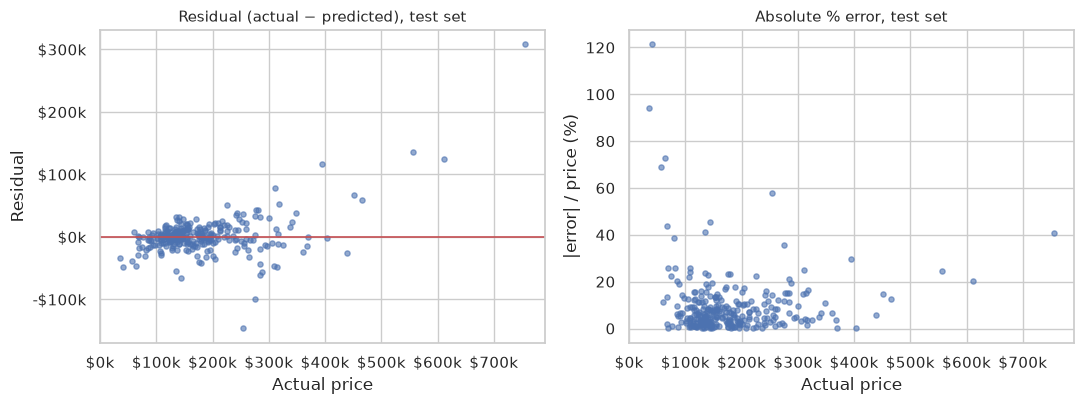

In [3]:
# does error grow with price?  absolute $ error and relative % error by price quintile (OOF train + test combined)
both = pd.concat([oof.assign(src="oof"), test.assign(src="test")])
both["price_bin"] = pd.qcut(both.actual, 5)
q = both.groupby("price_bin", observed=True).agg(n=("actual", "size"), mean_price=("actual", "mean"),
        MAE=("resid", lambda r: r.abs().mean()), median_pct_err=("pct_err", "median"),
        bias_mean_resid=("resid", "mean")).round(1)
print(q.to_string())
rho_abs = spearmanr(both.actual, both.resid.abs())[0]; rho_pct = spearmanr(both.actual, both.pct_err)[0]
print(f"\nSpearman(price, |error $|) = {rho_abs:.2f};  Spearman(price, |error %|) = {rho_pct:.2f}")
facts.update(rho_abs=rho_abs, rho_pct=rho_pct,
             q_mae_low=q.MAE.iloc[0], q_mae_high=q.MAE.iloc[-1],
             q_pct_low=q.median_pct_err.iloc[0], q_pct_high=q.median_pct_err.iloc[-1],
             q_bias_low=q.bias_mean_resid.iloc[0], q_bias_high=q.bias_mean_resid.iloc[-1])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(test.actual, test.resid, s=14, alpha=.6, color=BLUE)
ax[0].axhline(0, color=RED, lw=1.2)
ax[0].set_title("Residual (actual − predicted), test set"); ax[0].set_xlabel("Actual price"); ax[0].set_ylabel("Residual")
ax[1].scatter(test.actual, test.pct_err, s=14, alpha=.6, color=BLUE)
ax[1].set_title("Absolute % error, test set"); ax[1].set_xlabel("Actual price"); ax[1].set_ylabel("|error| / price (%)")
for a in ax: a.xaxis.set_major_formatter(usd_k)
ax[0].yaxis.set_major_formatter(usd_k)
plt.tight_layout(); plt.savefig(FIG / "04_residuals.png", dpi=130); plt.show()

## 2. Error by Neighborhood vs number of training houses

In [4]:
n_train = X_train.Neighborhood.value_counts().rename("n_train")
n_test = X_test.Neighborhood.value_counts().rename("n_test")
nb = (oof.groupby("Neighborhood").agg(oof_MAE=("resid", lambda r: r.abs().mean()),
                                      oof_med_pct=("pct_err", "median"), oof_log_err=("log_err", "mean"),
                                      mean_price=("actual", "mean"))
        .join(n_train).join(test.groupby("Neighborhood").agg(test_MAE=("resid", lambda r: r.abs().mean()),
                                                              test_med_pct=("pct_err", "median")))
        .join(n_test).fillna({"n_test": 0}).sort_values("n_train", ascending=False))
pd.set_option("display.width", 160)
print(nb.round(1).to_string())

              oof_MAE  oof_med_pct  oof_log_err  mean_price  n_train  test_MAE  test_med_pct  n_test
Neighborhood                                                                                        
NAmes         12325.8          5.8          0.1    147408.2      181    8341.8           4.8      44
CollgCr       11452.7          4.9          0.1    201112.0      115   11465.1           3.8      35
OldTown       15091.8          7.9          0.1    132886.9       91   11277.3           8.4      22
Edwards       17330.7          8.7          0.1    127908.9       87   14188.5           5.5      13
Somerst       18602.3          4.8          0.1    226403.8       69   13640.1           4.4      17
NWAmes        14929.1          6.0          0.1    189500.1       66    9721.8           5.0       7
Gilbert       11168.0          3.9          0.1    196540.6       65   11820.1           6.1      14
NridgHt       25150.6          4.9          0.1    312157.1       61   49333.3          12.

In [5]:
# Hypothesis: fewer training houses -> larger error.  Use OOF (all train houses, every neighborhood has >= n_train rows)
ok = nb[nb.n_train >= 10]          # drop 2 neighborhoods with < 10 houses (too few to estimate an error at all)
for col, name in [("oof_log_err", "mean |log error|"), ("oof_med_pct", "median % error")]:
    rho, p = spearmanr(ok.n_train, ok[col])
    print(f"Spearman(n_train, {name}) over {len(ok)} neighborhoods: rho={rho:+.2f}, p={p:.3f}")
    facts[f"nb_rho_{col}"], facts[f"nb_p_{col}"] = rho, p
top_mae = nb.sort_values("oof_MAE", ascending=False).head(3)
facts["top_mae_nb"] = top_mae.index.tolist(); facts["top_mae_vals"] = [float(v) for v in top_mae.oof_MAE]
facts["top_mae_ntrain"] = [int(v) for v in top_mae.n_train]
print("largest OOF MAE:", dict(zip(top_mae.index, top_mae.oof_MAE.round(0))))
rho, p = spearmanr(ok.n_train, ok.oof_log_err)
small, large = ok[ok.n_train < 30], ok[ok.n_train >= 30]
print(f"\nneighborhoods with 10-29 train houses: n={len(small)}, mean |log error| {small.oof_log_err.mean():.3f}, median % err {small.oof_med_pct.mean():.1f}")
print(f"neighborhoods with >=30 train houses : n={len(large)}, mean |log error| {large.oof_log_err.mean():.3f}, median % err {large.oof_med_pct.mean():.1f}")
# confounder check: price variability inside the neighborhood
cv_price = oof.groupby("Neighborhood").actual.agg(lambda s: s.std() / s.mean()).rename("price_cv")
ok = ok.join(cv_price)
rho_cv, p_cv = spearmanr(ok.price_cv, ok.oof_log_err)
print(f"Spearman(price variability inside neighborhood, error) = {rho_cv:+.2f}, p={p_cv:.2f}")
# all-houses view: error of houses in small vs large neighborhoods (house-level, OOF)
oof2 = oof.join(n_train, on="Neighborhood")
hs = oof2[oof2.n_train < 30].pct_err; hl = oof2[oof2.n_train >= 30].pct_err
print(f"house-level median % error: houses in neighborhoods with <30 train houses {hs.median():.1f}% (n={len(hs)}) vs >=30: {hl.median():.1f}% (n={len(hl)})")
facts.update(nb_rho=rho, nb_p=p, nb_n=len(ok), nb_rho_cv=rho_cv, nb_p_cv=p_cv,
             small_err=small.oof_log_err.mean(), large_err=large.oof_log_err.mean(),
             small_n=len(small), large_n=len(large), hs_med=hs.median(), hl_med=hl.median(),
             hs_n=len(hs), hl_n=len(hl))

Spearman(n_train, mean |log error|) over 22 neighborhoods: rho=-0.19, p=0.395
Spearman(n_train, median % error) over 22 neighborhoods: rho=-0.65, p=0.001
largest OOF MAE: {'NoRidge': 46257.0, 'StoneBr': 35041.0, 'NridgHt': 25151.0}

neighborhoods with 10-29 train houses: n=8, mean |log error| 0.097, median % err 8.8
neighborhoods with >=30 train houses : n=14, mean |log error| 0.088, median % err 6.3
Spearman(price variability inside neighborhood, error) = +0.45, p=0.03
house-level median % error: houses in neighborhoods with <30 train houses 7.7% (n=169) vs >=30: 5.9% (n=999)


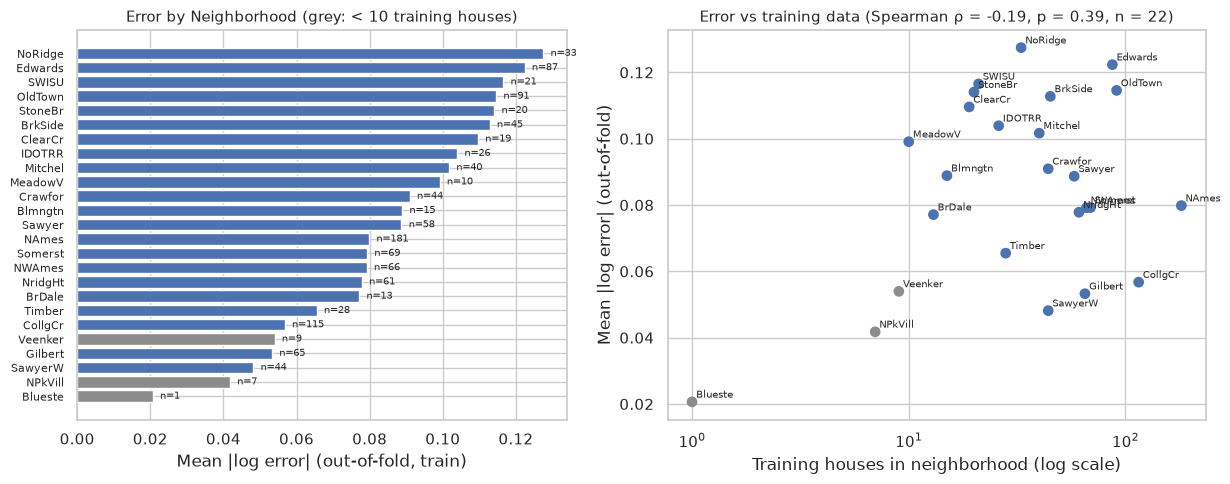

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 5), gridspec_kw={"width_ratios": [1, 1.1]})
d = nb.sort_values("oof_log_err")
cols = [GRAY if n < 10 else BLUE for n in d.n_train]
ax[0].barh(d.index, d.oof_log_err, color=cols)
for y_, (v, n) in enumerate(zip(d.oof_log_err, d.n_train)): ax[0].text(v + .002, y_, f"n={n}", va="center", fontsize=7)
ax[0].set_xlabel("Mean |log error| (out-of-fold, train)"); ax[0].set_title("Error by Neighborhood (grey: < 10 training houses)")
ax[0].tick_params(axis="y", labelsize=8)
big = nb.copy()
ax[1].scatter(big.n_train, big.oof_log_err, s=45, color=[GRAY if n < 10 else BLUE for n in big.n_train])
for name, r in big.iterrows(): ax[1].annotate(name, (r.n_train, r.oof_log_err), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax[1].set_xscale("log"); ax[1].set_xlabel("Training houses in neighborhood (log scale)"); ax[1].set_ylabel("Mean |log error| (out-of-fold)")
ax[1].set_title(f"Error vs training data (Spearman ρ = {rho:+.2f}, p = {p:.2f}, n = {len(ok)})")
plt.tight_layout(); plt.savefig(FIG / "04_neighborhood_error.png", dpi=130); plt.show()

In [7]:
# same view on the TEST set, but only neighborhoods with >= 8 test houses are meaningful
t = nb[nb.n_test >= 8][["n_train", "n_test", "test_MAE", "test_med_pct"]]
print(t.round(1).to_string())
print("\nneighborhoods with < 8 test houses (too few to read anything into):", int((nb.n_test < 8).sum()), "of", len(nb))

              n_train  n_test  test_MAE  test_med_pct
Neighborhood                                         
NAmes             181      44    8341.8           4.8
CollgCr           115      35   11465.1           3.8
OldTown            91      22   11277.3           8.4
Edwards            87      13   14188.5           5.5
Somerst            69      17   13640.1           4.4
Gilbert            65      14   11820.1           6.1
NridgHt            61      16   49333.3          12.0
Sawyer             58      16    8874.8           4.7
BrkSide            45      13    7413.5           1.9
SawyerW            44      15   16132.8           7.2
Mitchel            40       9   10310.7           5.3
NoRidge            33       8   65130.7          13.0
Timber             28      10   17772.9           3.9
IDOTRR             26      11   19619.6          19.5
ClearCr            19       9   25391.9          11.9

neighborhoods with < 8 test houses (too few to read anything into): 10 of 25


**How to read this.** Per-neighborhood errors on the test set rest on very few houses (most neighborhoods have < 10 test houses), so the main analysis uses out-of-fold predictions on the train split, where every house is predicted by a model that did not see it. Neighborhoods with fewer than 10 training houses are shown in grey and excluded from the correlation.

## 3. Ten worst predictions (test set)

In [8]:
worst = test.assign(pct_signed=test.resid / test.actual * 100).sort_values("pct_err", ascending=False).head(10)
cols = ["OverallQual", "OverallCond", "GrLivArea", "YearBuilt", "SaleCondition", "SaleType", "MSZoning"]
w = worst.join(X_test[cols])[["Neighborhood", "actual", "predicted", "pct_signed"] + cols]
w["actual"] = w.actual.map("${:,.0f}".format); w["predicted"] = w.predicted.map("${:,.0f}".format)
w["pct_signed"] = w.pct_signed.map("{:+.0f}%".format)
print(w.rename(columns={"pct_signed": "error (actual-pred)/actual"}).to_string())
allt = test.join(X_test[cols])
rest = allt.drop(worst.index)
wj = worst.join(X_test[cols])
over = int((worst.resid < 0).sum())
print(f"\nmodel OVER-predicted {over}/10 of the worst houses (under {10-over}/10)")
print(f"non-'Normal' SaleCondition: worst-10 {(wj.SaleCondition!='Normal').mean():.0%} vs rest {(rest.SaleCondition!='Normal').mean():.0%}")
print(f"OverallCond (mean): worst-10 {wj.OverallCond.mean():.2f} vs rest {rest.OverallCond.mean():.2f};  OverallQual: {wj.OverallQual.mean():.2f} vs {rest.OverallQual.mean():.2f}")
print(f"median price: worst-10 ${wj.actual.median():,.0f} vs rest ${rest.actual.median():,.0f}")
print(f"median n_train of neighborhood: worst-10 {worst.Neighborhood.map(n_train).median():.0f} vs rest {rest.Neighborhood.map(n_train).median():.0f}")
print("neighborhood counts among worst 10:", worst.Neighborhood.value_counts().to_dict())
print("share of total squared log error from these 10 houses: %.0f%%" % (100 * (worst.log_err**2).sum() / (test.log_err**2).sum()))
facts.update(w_over=over, w_nonnormal=(wj.SaleCondition != "Normal").mean(), r_nonnormal=(rest.SaleCondition != "Normal").mean(),
             w_cond=wj.OverallCond.mean(), r_cond=rest.OverallCond.mean(), w_qual=wj.OverallQual.mean(), r_qual=rest.OverallQual.mean(),
             w_price=wj.actual.median(), r_price=rest.actual.median(),
             w_sqshare=100 * (worst.log_err**2).sum() / (test.log_err**2).sum(),
             w_maxpct=worst.pct_err.max(), w_minpct=worst.pct_err.min())

     Neighborhood    actual predicted error (actual-pred)/actual  OverallQual  OverallCond  GrLivArea  YearBuilt SaleCondition SaleType   MSZoning
row                                                                                                                                               
30         IDOTRR   $40,000   $88,566                      -121%            4            4       1317       1920        Normal       WD  'C (all)'
916        IDOTRR   $35,311   $68,492                       -94%            2            3        480       1949       Abnorml       WD  'C (all)'
1432      OldTown   $64,500  $111,523                       -73%            4            6        968       1927        Normal       WD         RL
812        IDOTRR   $55,993   $94,540                       -69%            5            5       1044       1952        Alloca       WD  'C (all)'
581       NridgHt  $253,293  $399,792                       -58%            8            5       2042       2008      

In [9]:
# is the pattern also true on the larger out-of-fold set? (top 30 worst of 1168)
ow = oof.sort_values("pct_err", ascending=False).head(30).join(X_train[["SaleCondition", "OverallCond", "OverallQual"]])
orest = oof.drop(ow.index).join(X_train[["SaleCondition", "OverallCond", "OverallQual"]])
print(f"OOF top-30 worst: over-predicted {(ow.resid<0).mean():.0%}; non-Normal sale {(ow.SaleCondition!='Normal').mean():.0%} vs rest {(orest.SaleCondition!='Normal').mean():.0%};"
      f" OverallCond {ow.OverallCond.mean():.2f} vs {orest.OverallCond.mean():.2f}")
facts.update(o_over=(ow.resid < 0).mean(), o_nonnormal=(ow.SaleCondition != "Normal").mean(), o_rest_nonnormal=(orest.SaleCondition != "Normal").mean(),
             o_cond=ow.OverallCond.mean(), o_rest_cond=orest.OverallCond.mean())

OOF top-30 worst: over-predicted 80%; non-Normal sale 53% vs rest 17%; OverallCond 5.17 vs 5.60


## 4. Permutation importance (final model, test set)

     feature   mean    std
 OverallQual 0.0660 0.0027
    2ndFlrSF 0.0501 0.0039
    1stFlrSF 0.0493 0.0050
 TotalBsmtSF 0.0457 0.0048
   YearBuilt 0.0109 0.0018
 OverallCond 0.0091 0.0014
     LotArea 0.0081 0.0014
YearRemodAdd 0.0081 0.0018
    FullBath 0.0061 0.0014
   GrLivArea 0.0058 0.0011
 FireplaceQu 0.0054 0.0018
  CentralAir 0.0054 0.0007
  GarageCars 0.0047 0.0008
Neighborhood 0.0045 0.0014
 KitchenQual 0.0044 0.0011

top-3 share of total positive importance: 53%


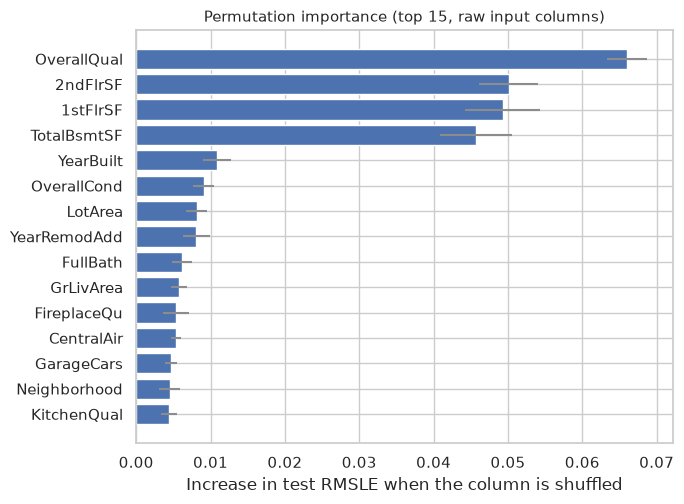

In [10]:
model = joblib.load("../models/final_model.joblib")
scorer = make_scorer(rmsle, greater_is_better=False)
pi = permutation_importance(model, X_test, y_test, scoring=scorer, n_repeats=10, random_state=42, n_jobs=-1)
imp = pd.DataFrame({"feature": X_test.columns, "mean": pi.importances_mean, "std": pi.importances_std}).sort_values("mean", ascending=False)
top = imp.head(15)
print(top.round(4).to_string(index=False))
print(f"\ntop-3 share of total positive importance: {top['mean'].head(3).sum() / imp['mean'].clip(lower=0).sum():.0%}")
fig, ax = plt.subplots(figsize=(7, 5.2))
t15 = top.iloc[::-1]
ax.barh(t15.feature, t15["mean"], xerr=t15["std"], color=BLUE, ecolor=GRAY)
ax.set_xlabel("Increase in test RMSLE when the column is shuffled"); ax.set_title("Permutation importance (top 15, raw input columns)")
plt.tight_layout(); plt.savefig(FIG / "04_permutation_importance.png", dpi=130); plt.show()
facts.update(pi_top=top.feature.tolist()[:5], pi_top_vals=[float(v) for v in top["mean"].head(5)],
             pi_top3_share=float(top['mean'].head(3).sum() / imp['mean'].clip(lower=0).sum()),
             pi_neigh_rank=int(imp.reset_index(drop=True).index[imp.reset_index(drop=True).feature == "Neighborhood"][0]) + 1,
             pi_neigh_val=float(imp.loc[imp.feature == "Neighborhood", "mean"].iloc[0]))

In [11]:
json.dump({k: (float(v) if isinstance(v, (np.floating, np.integer)) else v) for k, v in facts.items()},
          open(R / "analysis_facts.json", "w"), indent=1)
print("saved", len(facts), "facts")
from src.insights import write_insights
write_insights(); print("wrote reports/insights.md")

saved 56 facts
wrote reports/insights.md
